# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR

In [3]:
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [4]:
import shap

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
from platform import python_version

print(python_version())



3.10.12


In [7]:
!which python3

/usr/bin/python3


In [8]:
print(np.__version__)

1.26.3


# Load dataset

In [9]:
tt_set = pd.read_pickle("pickle_files/training_data_md.pkl")

In [7]:
tt_set.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,s1019,0,0,0,0,0,0,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [8]:
tt_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251242 entries, Line to MD
dtypes: float64(5), int64(251236), object(1)
memory usage: 4.6+ GB


In [9]:
#Final_data= Final_data.drop(['new_line'], axis=1)
tt_set.set_index('Line', inplace=True)
tt_set.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,0,0,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,0,0,0,0,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [12]:
full_pheno = tt_set.iloc[:, 251229:]
full_pheno.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,
s100,9.5000,6.26667,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,10.2133,4.00000,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,11.8200,7.78667,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,13.2800,6.94667,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,10.8400,7.34667,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [32]:
snps_loc= Final_data.drop(['MD', 'LL',	'LW', 'MD',	'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,0,2,2,0,2,0,0,0,0,1


In [33]:
snps_all= Final_data.drop(['MD', 'PRT'], axis=1)
snps_all.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52267177,Chr20_52267897,Chr20_52270629,BBD,LL,LW,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,61.0,9.5000,6.26667,154.700,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,37.0,10.2200,7.19333,130.000,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,77.0,10.3667,7.76667,111.733,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,42.0,11.8200,7.78667,73.000,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,2,0,0,62.0,14.2800,10.22000,95.700,0,0,1


In [ ]:
# Split training set into training and validation

In [52]:
X_train, X_test, y_train, y_test = train_test_split(snps, prt, test_size=0.2, random_state=42)

In [142]:
xgbreg = xgb.XGBRegressor(n_jobs =-1 , gamma= 1.0, learning_rate = 0.1, max_depth=7, n_estimators= 200)

In [143]:
xgbreg.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=1.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)

In [144]:
y_pred_xgboost = xgbreg.predict(X_test)

In [145]:
r2_score(y_test, y_pred_xgboost)

-0.15247130393981934

In [146]:
mse = mean_squared_error(y_test, y_pred_xgboost)

In [147]:
rmse = np.sqrt(mse)
print(rmse)

26.116685046019313


# Define all functions

In [10]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}


In [11]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [12]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [13]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [14]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [7]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [16]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# GWAS dataset

In [34]:
#Load file
genotype = pd.read_csv('../gwas_md/top_15percent_snps.012', sep='\t', header=None)
genotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Columns: 37685 entries, 0 to 37684
dtypes: int64(37685)
memory usage: 366.6 MB


In [35]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,37675,37676,37677,37678,37679,37680,37681,37682,37683,37684
0,0,0,1,0,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,1,0,1,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,2,0
2,2,0,1,0,1,0,0,1,0,0,...,0,0,2,0,0,0,0,0,0,1
3,3,2,1,0,1,0,0,1,0,0,...,0,0,1,0,0,1,0,1,0,0
4,4,0,1,0,1,0,0,0,0,0,...,0,0,2,0,0,0,0,0,2,0


In [36]:
genotype.set_index(genotype.columns[0], inplace =True)
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,37675,37676,37677,37678,37679,37680,37681,37682,37683,37684
0,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,2,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
1,0,1,1,0,0,0,0,0,0,2,...,0,0,0,1,0,1,0,0,2,0
2,0,1,0,1,0,0,1,0,0,2,...,0,0,2,0,0,0,0,0,0,1
3,2,1,0,1,0,0,1,0,0,1,...,0,0,1,0,0,1,0,1,0,0
4,0,1,0,1,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,2,0


In [37]:
column_names = pd.read_csv('../gwas_md/id_names_top15.txt', sep=' ', header=None)

In [38]:
column_names.head

<bound method NDFrame.head of                     0
0         Chr1_110522
1         Chr1_123323
2         Chr1_123346
3         Chr1_123617
4         Chr1_124784
...               ...
37679  Chr20_52020557
37680  Chr20_52212855
37681  Chr20_52247340
37682  Chr20_52255532
37683  Chr20_52266575

[37684 rows x 1 columns]>

In [39]:
genotype.columns = column_names
genotype.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1275 entries, 0 to 1274
Columns: 37684 entries, ('Chr1_110522',) to ('Chr20_52266575',)
dtypes: int64(37684)
memory usage: 366.6 MB


In [40]:
genotype.head()

,"(Chr1_110522,)","(Chr1_123323,)","(Chr1_123346,)","(Chr1_123617,)","(Chr1_124784,)","(Chr1_124994,)","(Chr1_128719,)","(Chr1_129283,)","(Chr1_131374,)","(Chr1_155648,)",...,"(Chr20_51890702,)","(Chr20_51890957,)","(Chr20_51891578,)","(Chr20_51895489,)","(Chr20_51958004,)","(Chr20_52020557,)","(Chr20_52212855,)","(Chr20_52247340,)","(Chr20_52255532,)","(Chr20_52266575,)"
0,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,2,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
1,0,1,1,0,0,0,0,0,0,2,...,0,0,0,1,0,1,0,0,2,0
2,0,1,0,1,0,0,1,0,0,2,...,0,0,2,0,0,0,0,0,0,1
3,2,1,0,1,0,0,1,0,0,1,...,0,0,1,0,0,1,0,1,0,0
4,0,1,0,1,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,2,0


In [41]:
#Adding row names
rows= pd.read_csv('../gwas_md/top_15percent_indv.txt', header=None)
rows.head()

,0
0,s63
1,s64
2,s66
3,s70
4,s71


In [42]:
genotype.index = rows
genotype.head()

,"(Chr1_110522,)","(Chr1_123323,)","(Chr1_123346,)","(Chr1_123617,)","(Chr1_124784,)","(Chr1_124994,)","(Chr1_128719,)","(Chr1_129283,)","(Chr1_131374,)","(Chr1_155648,)",...,"(Chr20_51890702,)","(Chr20_51890957,)","(Chr20_51891578,)","(Chr20_51895489,)","(Chr20_51958004,)","(Chr20_52020557,)","(Chr20_52212855,)","(Chr20_52247340,)","(Chr20_52255532,)","(Chr20_52266575,)"
"(s63,)",0,1,0,2,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
"(s64,)",0,1,1,0,0,0,0,0,0,2,...,0,0,0,1,0,1,0,0,2,0
"(s66,)",0,1,0,1,0,0,1,0,0,2,...,0,0,2,0,0,0,0,0,0,1
"(s70,)",2,1,0,1,0,0,1,0,0,1,...,0,0,1,0,0,1,0,1,0,0
"(s71,)",0,1,0,1,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,2,0


In [43]:
genotype.to_csv('genotype_top15_percent_md.txt', sep ='\t', index = True)

In [44]:
!sed 's/[,()\x27]//g'  genotype_top15_percent_md.txt > genotype_top15_percent_md_new.txt

In [45]:
#Load the genotype data
genotype_new = pd.read_csv('genotype_top15_percent_md_new.txt', sep = '\t')
genotype_new.head()

,Unnamed: 0,Chr1_110522,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_124784,Chr1_124994,Chr1_128719,Chr1_129283,Chr1_131374,...,Chr20_51890702,Chr20_51890957,Chr20_51891578,Chr20_51895489,Chr20_51958004,Chr20_52020557,Chr20_52212855,Chr20_52247340,Chr20_52255532,Chr20_52266575
0,s63,0,1,0,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,s64,0,1,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,2,0
2,s66,0,1,0,1,0,0,1,0,0,...,0,0,2,0,0,0,0,0,0,1
3,s70,2,1,0,1,0,0,1,0,0,...,0,0,1,0,0,1,0,1,0,0
4,s71,0,1,0,1,0,0,0,0,0,...,0,0,2,0,0,0,0,0,2,0


In [46]:
genotype_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Columns: 37685 entries, Unnamed: 0 to Chr20_52266575
dtypes: int64(37684), object(1)
memory usage: 366.6+ MB


In [47]:
#Setting the index and naming the index column 
genotype_new = genotype_new.rename(columns={genotype_new.columns[0]: 'Line'})
genotype_new.set_index(genotype_new.columns[0])

,Chr1_110522,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_124784,Chr1_124994,Chr1_128719,Chr1_129283,Chr1_131374,Chr1_155648,...,Chr20_51890702,Chr20_51890957,Chr20_51891578,Chr20_51895489,Chr20_51958004,Chr20_52020557,Chr20_52212855,Chr20_52247340,Chr20_52255532,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,1,0,2,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
s64,0,1,1,0,0,0,0,0,0,2,...,0,0,0,1,0,1,0,0,2,0
s66,0,1,0,1,0,0,1,0,0,2,...,0,0,2,0,0,0,0,0,0,1
s70,2,1,0,1,0,0,1,0,0,1,...,0,0,1,0,0,1,0,1,0,0
s71,0,1,0,1,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s2894,1,1,1,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,2,0
s2895,0,1,1,1,0,1,0,1,1,0,...,1,1,1,0,0,0,2,0,0,0
s2896,1,1,0,0,0,0,1,0,0,2,...,0,0,0,0,0,1,0,0,0,0


In [48]:
full_pheno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LL                 2450 non-null   float64
 1   LW                 2450 non-null   float64
 2   PLH                2450 non-null   float64
 3   VBN                2450 non-null   float64
 4   BeiJing_2013       2450 non-null   int64  
 5   HeNan_2014         2450 non-null   int64  
 6   HeNan_2015         2450 non-null   int64  
 7   HeiLongJiang_2014  2450 non-null   int64  
 8   HeiLongJiang_2015  2450 non-null   int64  
 9   improved_cultivar  2450 non-null   int64  
 10  landrace           2450 non-null   int64  
 11  MD                 2450 non-null   float64
dtypes: float64(5), int64(7)
memory usage: 248.8+ KB


In [49]:
gwas_data = pd.merge(genotype_new, full_pheno, on='Line', how='outer', indicator=False)
gwas_data.head()

,Line,Chr1_110522,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_124784,Chr1_124994,Chr1_128719,Chr1_129283,Chr1_131374,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s100,0,1,0,1,1,0,0,1,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
1,s100,0,1,0,1,1,0,0,1,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
2,s101,1,0,0,0,0,1,1,0,0,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
3,s1014,1,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
4,s1014,1,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [50]:
gwas_data = gwas_data.set_index('Line')
gwas_data.head()

,Chr1_110522,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_124784,Chr1_124994,Chr1_128719,Chr1_129283,Chr1_131374,Chr1_155648,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,1,1,0,0,1,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,0,1,0,1,1,0,0,1,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,1,0,0,0,0,1,1,0,0,0,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,1,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,1,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [34]:
gwas_data= gwas_data.drop(['index'], axis=1)

In [51]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 37696 entries, Chr1_110522 to MD
dtypes: float64(5), int64(37691)
memory usage: 704.6+ MB


In [52]:
gwas_data.head()

,Chr1_110522,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_124784,Chr1_124994,Chr1_128719,Chr1_129283,Chr1_131374,Chr1_155648,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,1,1,0,0,1,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,0,1,0,1,1,0,0,1,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,1,0,0,0,0,1,1,0,0,0,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,1,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,1,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


# GWAS all traits

In [25]:
#gwas_data.to_pickle("GWAS_top15percent_md_data.pkl")
gwas_data = pd.read_pickle("../pickle_files/GWAS_top10percent_md_data.pkl")
gwas_data.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,0,1,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,0,0,1,0,1,0,0,0,0,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [26]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 25135 entries, Chr1_123323 to MD
dtypes: float64(5), int64(25130)
memory usage: 469.8+ MB


In [27]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [28]:
gwas_all= gwas_data.drop(['MD'], axis=1)
gwas_all.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,1,0,0,0,0,0,0,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [29]:
gwas_all_dupe= gwas_data.drop(['MD'], axis=1)
gwas_all_dupe.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,1,0,0,0,0,0,0,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


# Run models

In [21]:
X_train, X_test, y_train, y_test = train_test_split(gwas_all, gwas_y, test_size=0.1, random_state=42)

In [22]:
X_train.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,0,1,0,0,0,0,0,0,0,...,6.55333,77.6,1.20000,0,1,0,0,0,1,0
s2862,1,0,0,0,2,0,0,1,1,0,...,5.77333,49.0,1.60000,0,0,1,0,0,1,0
s308,1,0,0,0,2,0,0,0,1,0,...,7.44000,104.0,5.00000,0,1,0,0,0,0,1
s202,0,0,0,0,0,0,0,0,0,0,...,6.00000,22.7,3.33333,1,0,0,0,0,1,0
s614,0,0,0,0,0,0,0,1,1,0,...,6.58667,86.0,3.40000,0,1,0,0,0,1,0


In [23]:
X_train = X_train.to_numpy()

In [24]:
y_train = y_train.to_numpy()

In [25]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.775258662348743), ('colsample_bytree', 0.6039414741578638), ('gamma', 0.006095753914072028), ('learning_rate', 0.04721070399187305), ('max_delta_step', 0), ('max_depth', 50), ('min_child_weight', 9), ('n_estimators', 200), ('reg_alpha', 1.0), ('reg_lambda', 1e-09), ('subsample', 0.5095537639593067)])


In [13]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.775258662348743), ('colsample_bytree', 0.6039414741578638), ('gamma', 0.006095753914072028), ('learning_rate', 0.04721070399187305), ('max_delta_step', 0), ('max_depth', 50), ('min_child_weight', 9), ('n_estimators', 200), ('reg_alpha', 1.0), ('reg_lambda', 1e-09), ('subsample', 0.5095537639593067)])

In [26]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.718581449951362
RMSE for dataset is:8.585038601950366& mean of this fold is 117.89183673469388
this is 7.282131519649071% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6265998243267981
RMSE for dataset is:9.706755389809784& mean of this fold is 117.55510204081632
this is 8.257196175491814% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7112520799354805
RMSE for dataset is:8.433327332646796& mean of this fold is 116.04489795918367
this is 7.267296952265009% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6188678701136798
RMSE for dataset is:9.380231403175495& mean of this fold is 115.26938775510204
this is 8.13766047157677% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6886406013829232
RMSE for dataset

In [38]:
#pickle.dump(best_xgbr_model, open("gwas_top10_allfeats_xgbr_md.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_allfeats_xgbr_md.pickle.dat", "rb"))

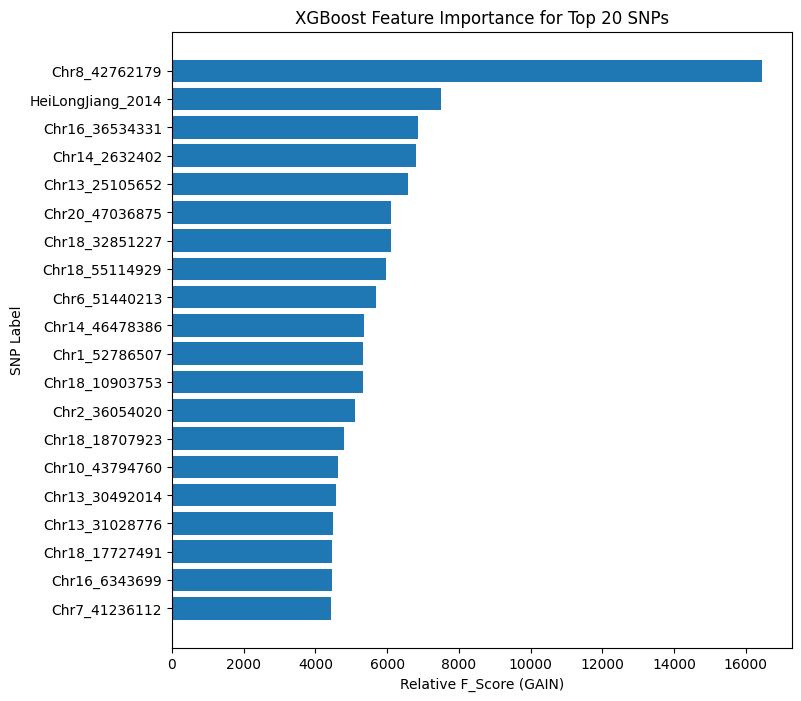

In [28]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_all_dupe, top_n=20)

In [29]:
explainer = shap.Explainer(best_xgbr_model)

In [30]:
shap_values = explainer(gwas_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

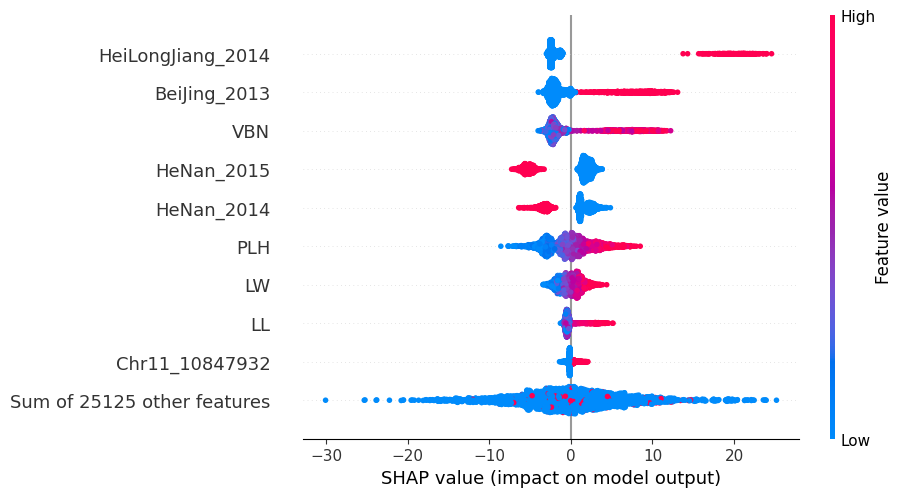

In [31]:
shap.plots.beeswarm(shap_values, show=False)

In [14]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [15]:
holdout_data = holdout_data.set_index('Line')

In [16]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [39]:
X_holdout = holdout_data.iloc[:, 0:251240]

In [40]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [41]:
y_holdout = holdout_data.iloc[:, 251240:]

In [42]:
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [43]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [44]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 25134 entries, Chr1_123323 to landrace
dtypes: float64(4), int64(25130)
memory usage: 117.6+ MB


In [45]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.75
RMSE of Holdout: 9.60
Mean of Holdout: 117.42
This is 8.17% of the mean pheno data
0 117.0 116.36313
1 148.0 142.304
2 117.0 116.61361
3 121.0 128.46126
4 119.0 120.7826


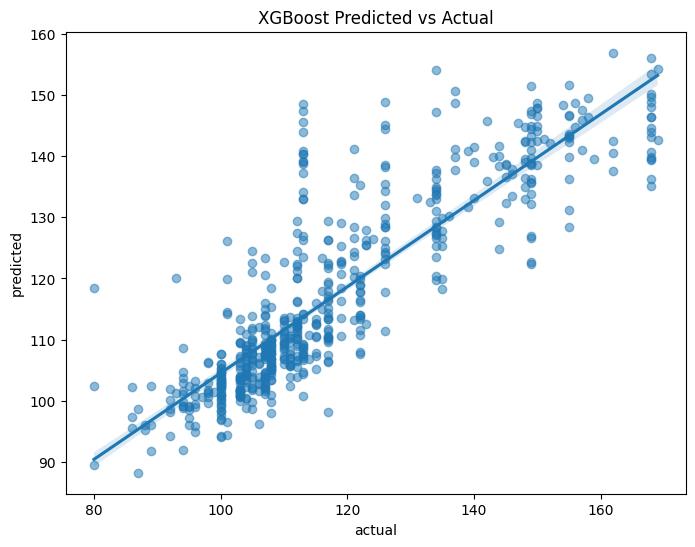

In [46]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [43]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 117.0 116.36313
1 148.0 142.304
2 117.0 116.61361
3 121.0 128.46126
4 119.0 120.7826
5 94.0 98.74197


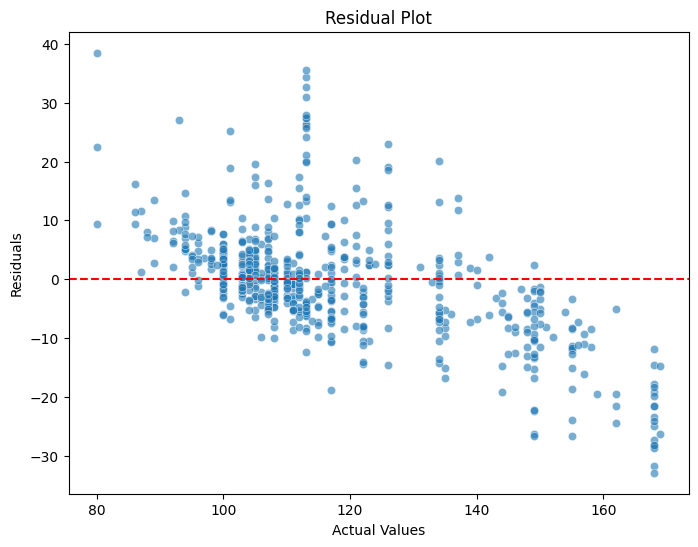

In [44]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [45]:
#### RF models

In [46]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 28), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 58)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 28), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 58)])

In [47]:
best_rfr_model = eval_k_fold(best_rfreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -16.13651099078084
RMSE for dataset is:16.126699505335935& mean of this fold is 114.85306122448979
this is 14.041157748346794% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -23.15933145390418
RMSE for dataset is:19.47980583475403& mean of this fold is 116.95102040816326
this is 16.65637953971569% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -22.93384636321283
RMSE for dataset is:18.314806061561438& mean of this fold is 115.68163265306123
this is 15.832077782381454% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -22.25718637498245
RMSE for dataset is:18.184506719081416& mean of this fold is 115.66734693877551
this is 15.721383087230963% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -18.48957385820733
RMSE for

In [48]:
pickle.dump(best_rfr_model, open("gwas_top10_allfeats_rfr_md.pickle.dat", "wb"))

In [47]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_allfeats_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.13
RMSE of Holdout: 18.06
Mean of Holdout: 117.42
This is 15.38% of the mean pheno data
0 117.0 121.48229886775484
1 148.0 116.07666220295835
2 117.0 113.47298018460103
3 121.0 122.11100362818772
4 119.0 122.77273019224809


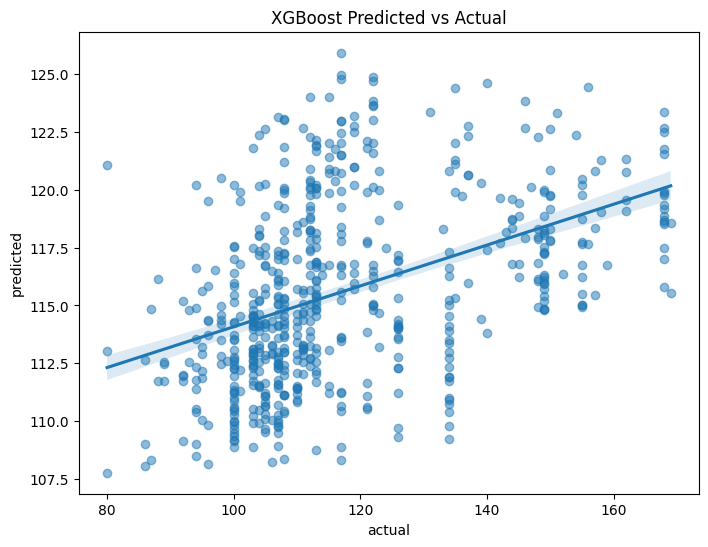

In [48]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [50]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits


/home/supadhyaya/.local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [51]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7194365969725276
RMSE for dataset is:9.075057898783685& mean of this fold is 115.72857142857143
this is 7.841674520612986% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7808320972647822
RMSE for dataset is:8.614468430199198& mean of this fold is 119.88979591836734
this is 7.185322457354726% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7619845146627501
RMSE for dataset is:8.546631026950617& mean of this fold is 114.64897959183673
this is 7.454607147292183% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7372140856601352
RMSE for dataset is:8.972911858204958& mean of this fold is 115.37551020408164
this is 7.777137316518252% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7160791582074064
RMSE for datas

In [53]:
pickle.dump(best_svr_model, open("gwas_top10_allfeats_svr_md.pickle.dat", "wb"))

In [49]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_allfeats_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.75
RMSE of Holdout: 9.66
Mean of Holdout: 117.42
This is 8.23% of the mean pheno data
0 117.0 119.28457621726162
1 148.0 144.75408836775355
2 117.0 118.07996966868782
3 121.0 124.22978444023434
4 119.0 124.26955915254953


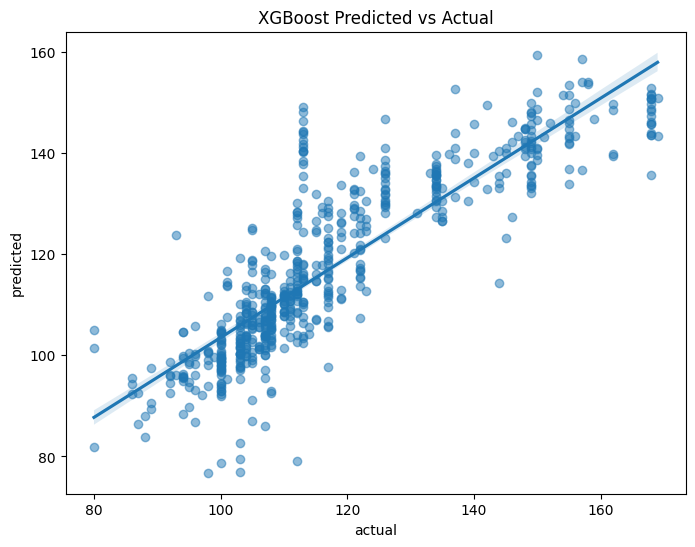

In [50]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [51]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 25135 entries, Chr1_123323 to MD
dtypes: float64(5), int64(25130)
memory usage: 469.8+ MB


In [52]:
gwas_snps = gwas_data.iloc[:, 0:25123]
gwas_snps.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_51666785,Chr20_51679540,Chr20_51888995,Chr20_51890957,Chr20_51895489,Chr20_51958004,Chr20_52212855,Chr20_52247340,Chr20_52255532,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s101,0,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,2,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
gwas_snps_dupe = gwas_data.iloc[:, 0:25123]
gwas_snps_dupe.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_51666785,Chr20_51679540,Chr20_51888995,Chr20_51890957,Chr20_51895489,Chr20_51958004,Chr20_52212855,Chr20_52247340,Chr20_52255532,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s101,0,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,2,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


# Run models

In [59]:
X_train, X_test, y_train, y_test = train_test_split(gwas_snps, gwas_y, test_size=0.1, random_state=42)

In [43]:
X_train.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51494122,Chr20_51594636,Chr20_51666785,Chr20_51684283,Chr20_51840551,Chr20_51859725,Chr20_51891017,Chr20_51977670,Chr20_52108115,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s2502,0,2,0,0,0,0,2,0,0,2,...,2,0,0,2,0,0,0,0,0,0
s286,0,0,0,0,0,0,1,0,0,0,...,2,0,0,0,0,0,0,0,0,0
s382,0,0,0,2,2,0,0,2,0,0,...,0,0,0,2,0,0,0,0,0,0
s789,1,1,1,0,0,0,2,0,0,2,...,2,0,0,2,0,0,0,0,0,0
s691,0,0,0,2,0,0,1,0,0,0,...,2,2,0,2,0,0,0,0,0,0


In [62]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [63]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])


In [54]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])

OrderedDict([('colsample_bylevel', 0.9132100359267209), ('colsample_bytree', 0.7679711803126804), ('gamma', 2.428808912219129e-07), ('learning_rate', 0.03511167856740689), ('max_delta_step', 3), ('max_depth', 8), ('min_child_weight', 4), ('n_estimators', 197), ('reg_alpha', 0.023358352781682152), ('reg_lambda', 2.1396512525873352e-07), ('scale_pos_weight', 0.001760608876847004), ('subsample', 0.15990388740095085)])


In [64]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -51.02271908594173
RMSE for dataset is:19.769618995135325& mean of this fold is 117.18979591836735
this is 16.869744366571425% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -37.36399940613837
RMSE for dataset is:18.857345674782767& mean of this fold is 116.3061224489796
this is 16.213545149400872% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -40.265809430857274
RMSE for dataset is:17.59299456701248& mean of this fold is 116.77551020408163
this is 15.065654208032358% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -32.89345848410912
RMSE for dataset is:17.983800949752474& mean of this fold is 113.87755102040816
this is 15.79222664046364% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -47.21781004699774
RMSE for

In [65]:
pickle.dump(best_xgbr_model, open("gwas_top10_onlysnps_xgbr_md.pickle.dat", "wb"))

In [55]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlysnps_xgbr_md.pickle.dat", "rb"))

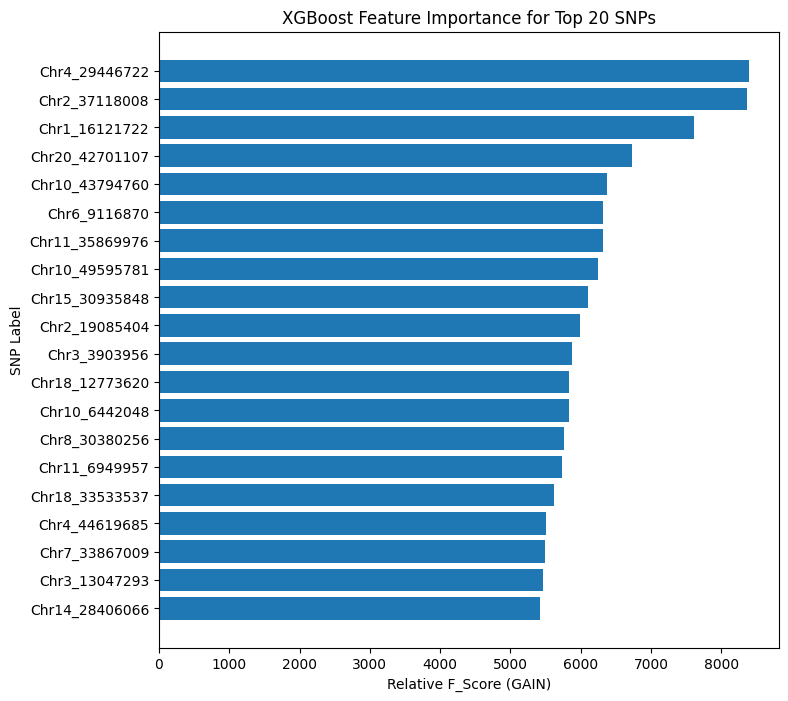

In [66]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_snps_dupe , top_n=20)

In [67]:
explainer = shap.Explainer(best_xgbr_model)

In [68]:
shap_values = explainer(gwas_snps_dupe)

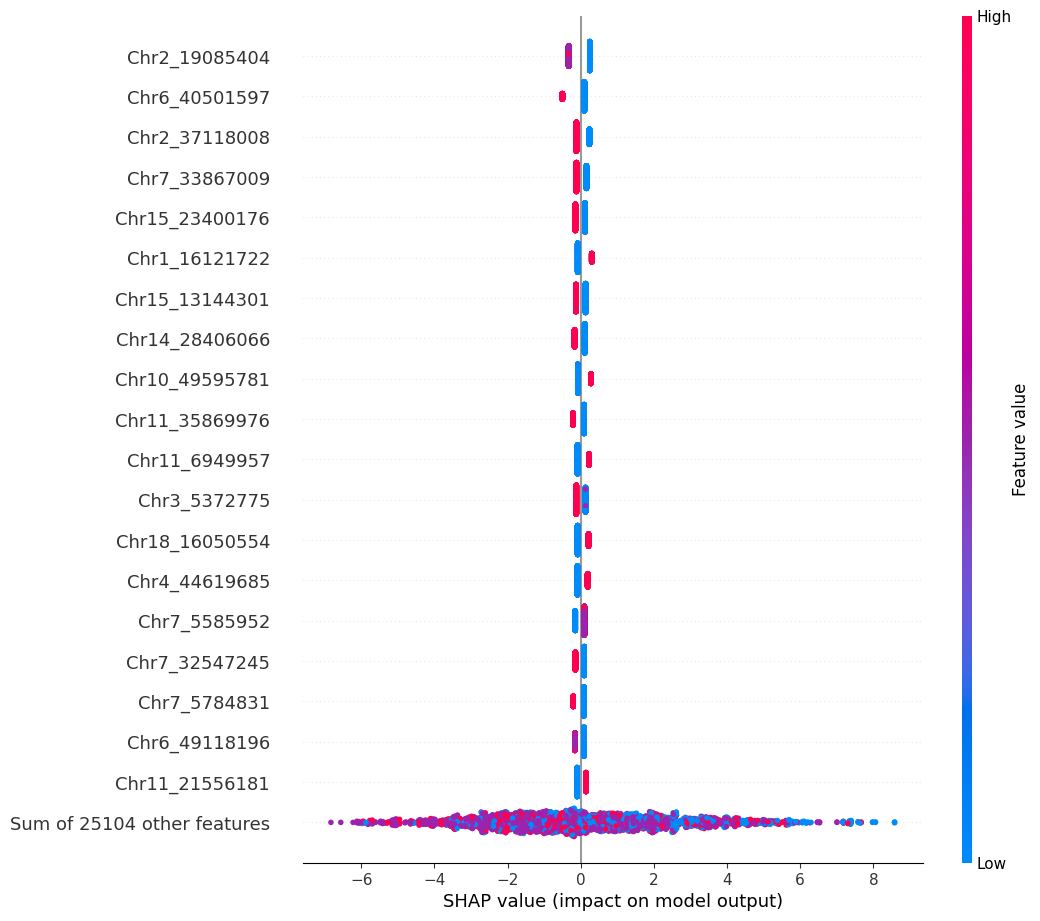

In [69]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [70]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [71]:
holdout_data = holdout_data.set_index('Line')

In [56]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [57]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [58]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [59]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 25123 entries, Chr1_123323 to Chr20_52266575
dtypes: int64(25123)
memory usage: 117.5+ MB


In [60]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.03
RMSE of Holdout: 19.06
Mean of Holdout: 117.42
This is 16.23% of the mean pheno data
0 117.0 124.32327
1 148.0 114.66002
2 117.0 113.23467
3 121.0 122.84575
4 119.0 122.84575


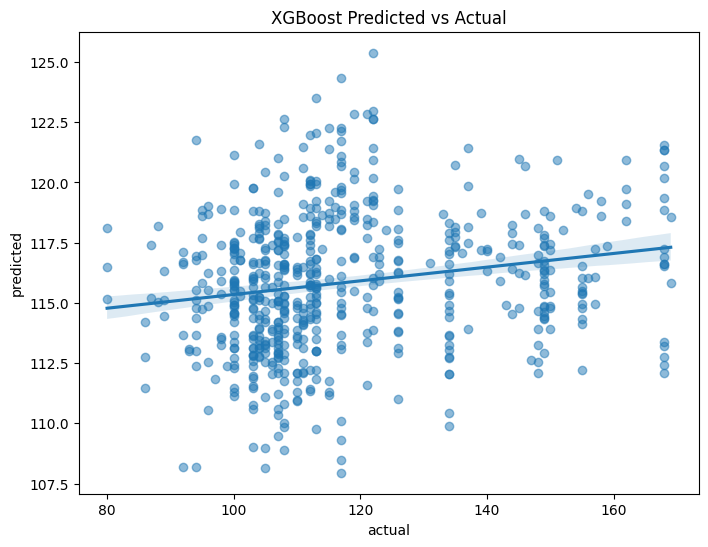

In [61]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [78]:
#### RF models

In [79]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 3), ('max_features', 'sqrt'), ('max_samples', 0.8894947927467769), ('min_samples_leaf', 9), ('min_samples_split', 20), ('n_estimators', 222)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 3), ('max_features', 'sqrt'), ('max_samples', 0.8894947927467769), ('min_samples_leaf', 9), ('min_samples_split', 20), ('n_estimators', 222)])

In [80]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -214.35945693765393
RMSE for dataset is:18.895535224274756& mean of this fold is 116.35510204081632
this is 16.239541621171348% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -222.3993282833833
RMSE for dataset is:18.359211892279188& mean of this fold is 115.99591836734695
this is 15.827463716557236% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -237.64106407468324
RMSE for dataset is:19.242461918933394& mean of this fold is 117.53061224489795
this is 16.372297864694154% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -164.58833670772046
RMSE for dataset is:17.435542575086927& mean of this fold is 114.78775510204082
this is 15.1893749987423% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -205.29092688180148
RMSE

In [81]:
pickle.dump(best_rfr_model, open("gwas_top10_onlysnps_rfr_md.pickle.dat", "wb"))

In [62]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlysnps_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.02
RMSE of Holdout: 19.11
Mean of Holdout: 117.42
This is 16.27% of the mean pheno data
0 117.0 116.47010095529815
1 148.0 116.26332893257374
2 117.0 113.66323746488206
3 121.0 117.3856675647693
4 119.0 117.3856675647693


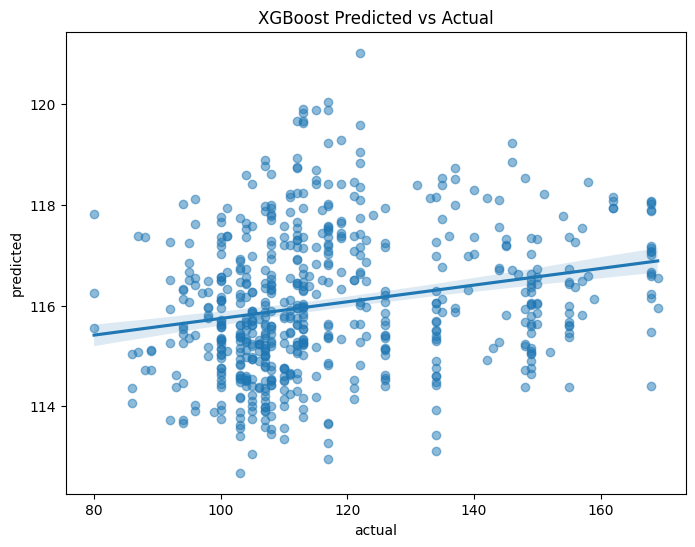

In [63]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [83]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1), ('kernel', 'sigmoid')])


In [84]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -53.50530198430796
RMSE for dataset is:19.455217759232767& mean of this fold is 116.0734693877551
this is 16.76112367610953% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -79.97839177054256
RMSE for dataset is:20.423922917285548& mean of this fold is 118.15510204081633
this is 17.285688526789276% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -46.73164201064878
RMSE for dataset is:16.725924129184946& mean of this fold is 114.43265306122449
this is 14.616391110180881% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -50.65350435202501
RMSE for dataset is:18.636058390112062& mean of this fold is 115.91428571428571
this is 16.0774474649722% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -56.45297366400566
RMSE for d

In [85]:
pickle.dump(best_svr_model, open("gwas_top10_onlysnps_svr_md.pickle.dat", "wb"))

In [64]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlysnps_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: -0.07
RMSE of Holdout: 19.98
Mean of Holdout: 117.42
This is 17.01% of the mean pheno data
0 117.0 111.47061749253587
1 148.0 110.27388429921332
2 117.0 108.5617930482726
3 121.0 113.12854796355583
4 119.0 113.12854796355583


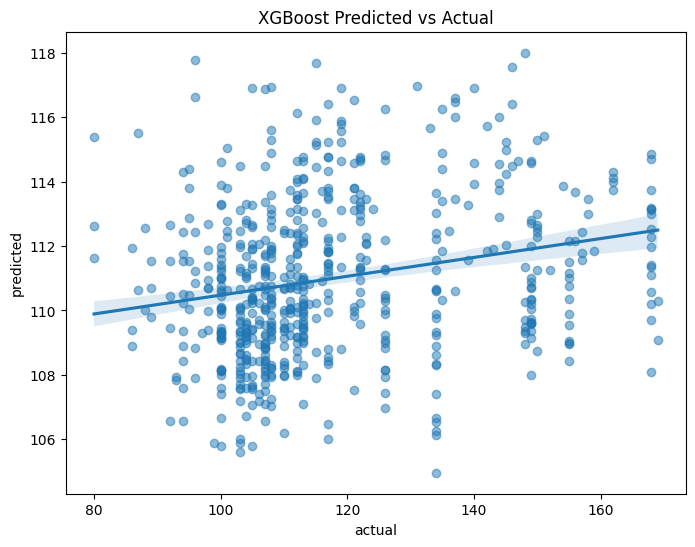

In [65]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [66]:
gwas_loc= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_52247340,Chr20_52255532,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,1,0,0,0,0,0,1
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,0,0,1,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,1,2,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [67]:
gwas_loc_dupe= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_52247340,Chr20_52255532,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,1,0,0,0,0,0,1
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,0,0,1,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,1,2,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [68]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 25130 entries, Chr1_123323 to landrace
dtypes: int64(25130)
memory usage: 469.7+ MB


In [69]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [70]:
# Run models

In [25]:
X_train, X_test, y_train, y_test = train_test_split(gwas_loc, gwas_y, test_size=0.1, random_state=42)

In [26]:
X_train.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_52247340,Chr20_52255532,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
s2862,1,0,0,0,2,0,0,1,1,0,...,0,0,0,0,0,1,0,0,1,0
s308,1,0,0,0,2,0,0,0,1,0,...,0,0,1,0,1,0,0,0,0,1
s202,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
s614,0,0,0,0,0,0,0,1,1,0,...,0,2,0,0,1,0,0,0,1,0


In [27]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [28]:
print(y_train[~np.isfinite(y_train)])

[]


In [29]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.8701037752233659), ('colsample_bytree', 0.8952092700426295), ('gamma', 0.0032558682913788545), ('learning_rate', 0.25004045612688347), ('max_delta_step', 3), ('max_depth', 4), ('min_child_weight', 8), ('n_estimators', 200), ('reg_alpha', 4.5915819680872573e-07), ('reg_lambda', 18.600552940918313), ('subsample', 0.6433375043498343)])


In [70]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.8701037752233659), ('colsample_bytree', 0.8952092700426295), ('gamma', 0.0032558682913788545), ('learning_rate', 0.25004045612688347), ('max_delta_step', 3), ('max_depth', 4), ('min_child_weight', 8), ('n_estimators', 200), ('reg_alpha', 4.5915819680872573e-07), ('reg_lambda', 18.600552940918313), ('subsample', 0.6433375043498343)])

OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 2), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('scale_pos_weight', 0.060830282487222144), ('subsample', 0.13556548021189216)])


In [30]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6964695138019943
RMSE for dataset is:9.2881569533207& mean of this fold is 117.82857142857142
this is 7.882771420131535% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6951188701056206
RMSE for dataset is:8.668021933621514& mean of this fold is 115.4734693877551
this is 7.506505156188438% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7177540717980978
RMSE for dataset is:9.091705704435439& mean of this fold is 116.9469387755102
this is 7.7742143570664615% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6840204387277644
RMSE for dataset is:9.181164846189445& mean of this fold is 114.93877551020408
this is 7.987874244731584% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7023354095141299
RMSE for dataset 

In [71]:
#pickle.dump(best_xgbr_model, open("gwas_top10_onlyloc_xgbr_md.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlyloc_xgbr_md.pickle.dat", "rb"))

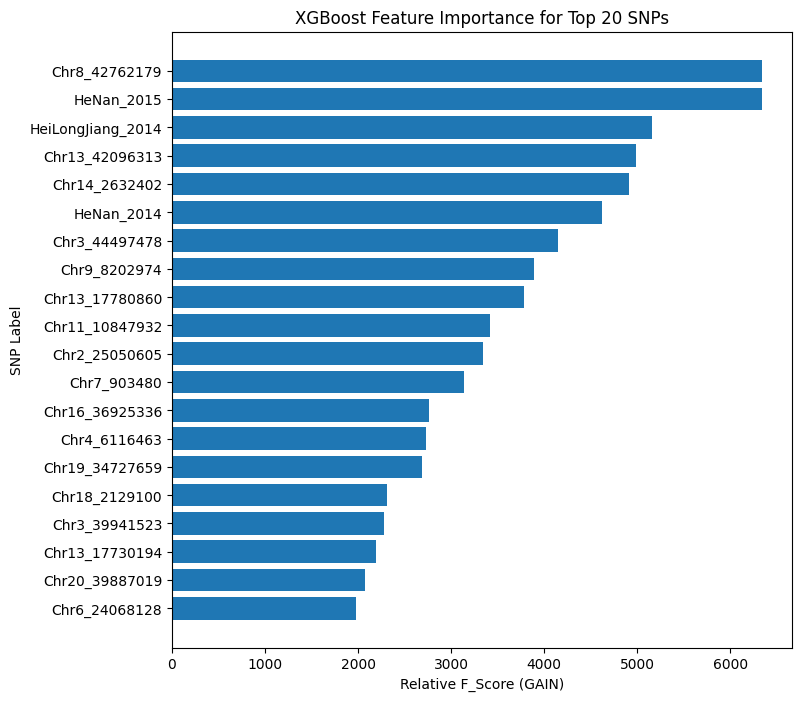

In [32]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_loc_dupe, top_n=20)

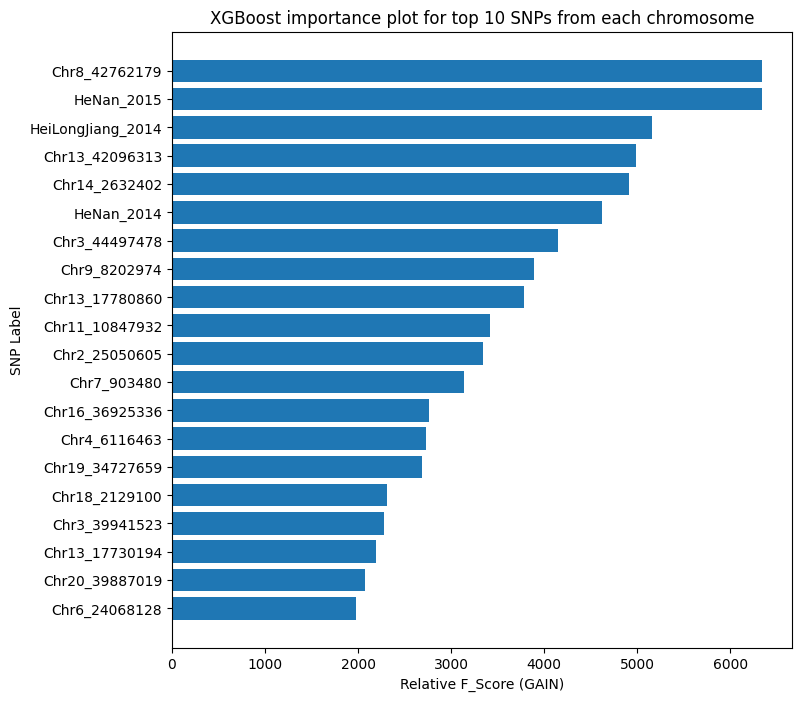

In [39]:
f_names = ['f' + str(i) for i in range(len(gwas_loc_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[gwas_loc_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('md_xgbr_GWAS10_onlyloc_FI.png', dpi=300, bbox_inches='tight')

In [40]:
explainer = shap.Explainer(best_xgbr_model)

In [41]:
shap_values = explainer(gwas_loc_dupe, check_additivity=False)

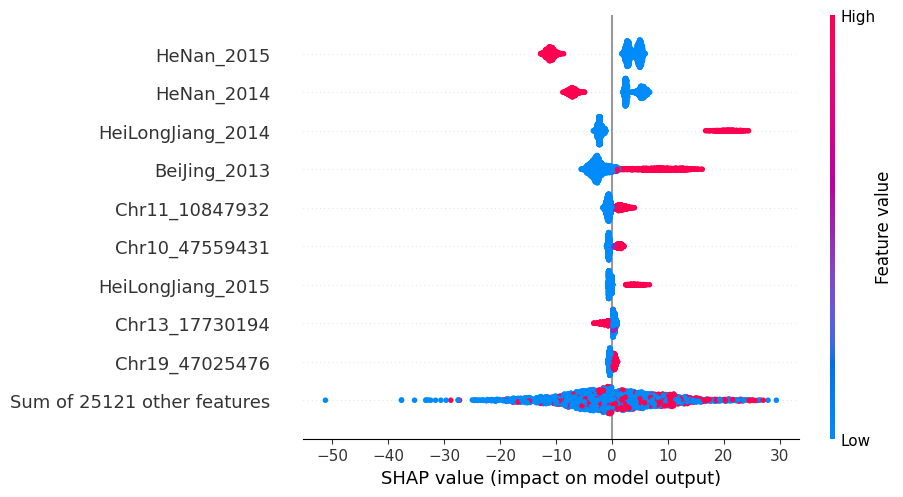

In [42]:
shap.plots.beeswarm(shap_values, show=False)
plt.savefig('md_xgbr_GWAS10_onlyloc_shap.png', dpi=300, bbox_inches='tight')

In [29]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [30]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [72]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [73]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [74]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [75]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 25130 entries, Chr1_123323 to landrace
dtypes: int64(25130)
memory usage: 117.5+ MB


In [76]:
X_holdout.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_52247340,Chr20_52255532,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
s1019,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,1,2,0,1,0,0,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,1,2,0,0,0,0,0,1,0,1


In [77]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.77
RMSE of Holdout: 9.34
Mean of Holdout: 117.42
This is 7.96% of the mean pheno data
0 117.0 120.46235
1 148.0 150.1037
2 117.0 117.25056
3 121.0 126.45664
4 119.0 126.65632


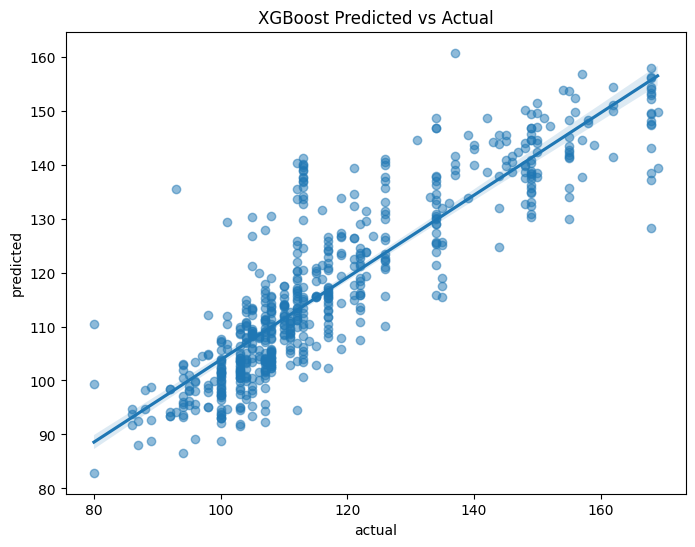

In [78]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

0 117.0 120.46235
1 148.0 150.1037
2 117.0 117.25056
3 121.0 126.45664
4 119.0 126.65632
5 94.0 93.58055


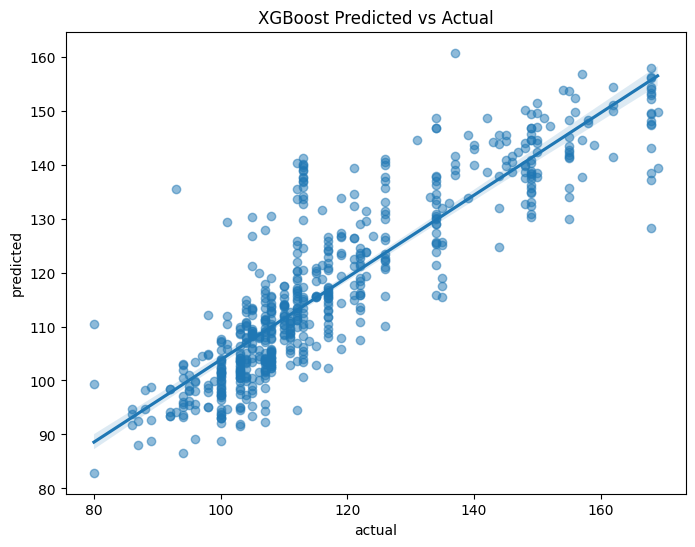

In [45]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])
# Create a DataFrame for plotting
thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
plt.title('XGBoost Predicted vs Actual')
plt.savefig('md_xgbr_GWAS10_onlyloc_pav.png', dpi=300, bbox_inches='tight')

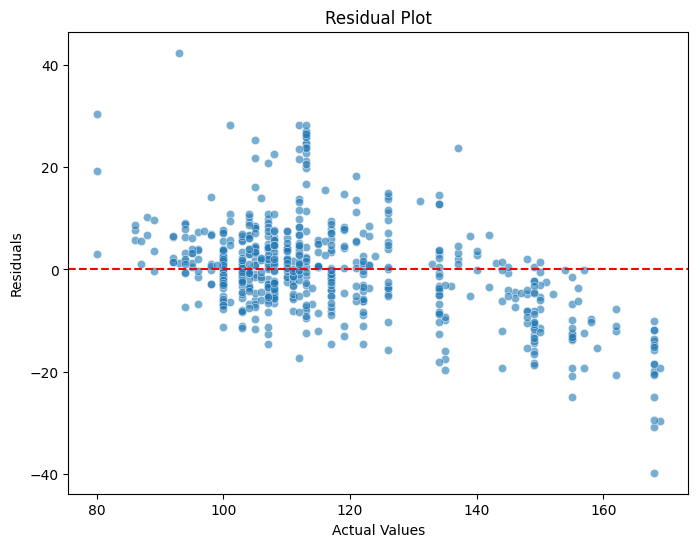

In [46]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.savefig('md_xgbr_GWAS10_onlyloc_residual.png', dpi=300, bbox_inches='tight')

In [47]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 49), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 458)])


In [2]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 49), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 458)])

In [49]:
gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -20.054779685317516
RMSE for dataset is:17.274261313541274& mean of this fold is 115.0530612244898
this is 15.014169227393259% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -30.34207229893418
RMSE for dataset is:18.964354744287398& mean of this fold is 117.2265306122449
this is 16.17752794119327% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -19.01922952686587
RMSE for dataset is:16.808504350790137& mean of this fold is 115.53877551020408
this is 14.547933606329119% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -18.807631665806635
RMSE for dataset is:15.462510516023574& mean of this fold is 113.65306122448979
this is 13.605010150568416% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -22.249272846376645
RMSE f

In [50]:
pickle.dump(best_rfr_model, open("gwas_top10_onlyloc_rfr_md.pickle.dat", "wb"))

In [79]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlyloc_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.09
RMSE of Holdout: 18.46
Mean of Holdout: 117.42
This is 15.72% of the mean pheno data
0 117.0 121.2669232479109
1 148.0 115.84883964002736
2 117.0 113.5504413099566
3 121.0 121.23732831360982
4 119.0 121.00092284286902


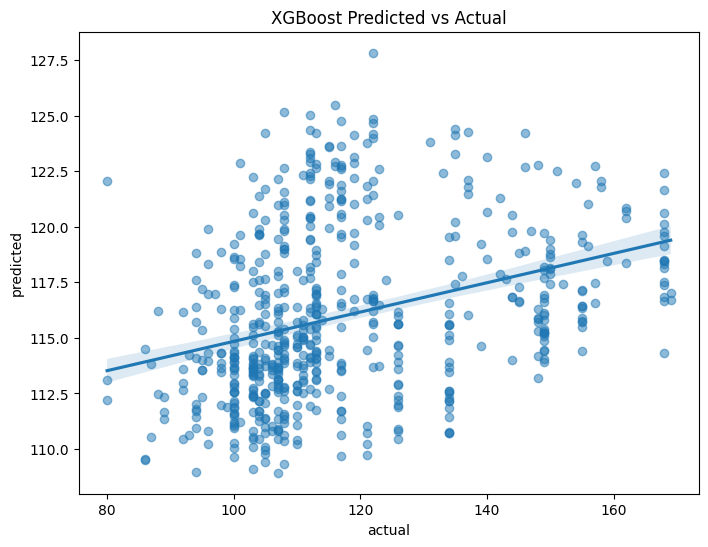

In [80]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [52]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [53]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7485431803986934
RMSE for dataset is:9.322281138869398& mean of this fold is 115.45102040816326
this is 8.074663269247504% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7337233946917765
RMSE for dataset is:9.114424985833288& mean of this fold is 116.2734693877551
this is 7.8387830292033405% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7569716697997776
RMSE for dataset is:8.410312202423786& mean of this fold is 115.39591836734694
this is 7.288223293696333% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7912814173596489
RMSE for dataset is:8.492069895294954& mean of this fold is 115.87346938775511
this is 7.328743965434723% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7502155521004465
RMSE for datas

In [54]:
pickle.dump(best_svr_model, open("gwas_top10_onlyloc_svr_md.pickle.dat", "wb"))

In [81]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlyloc_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.74
RMSE of Holdout: 9.92
Mean of Holdout: 117.42
This is 8.45% of the mean pheno data
0 117.0 120.5004065712836
1 148.0 140.89883937366207
2 117.0 114.5002736503487
3 121.0 128.3591705850175
4 119.0 129.35929973026563


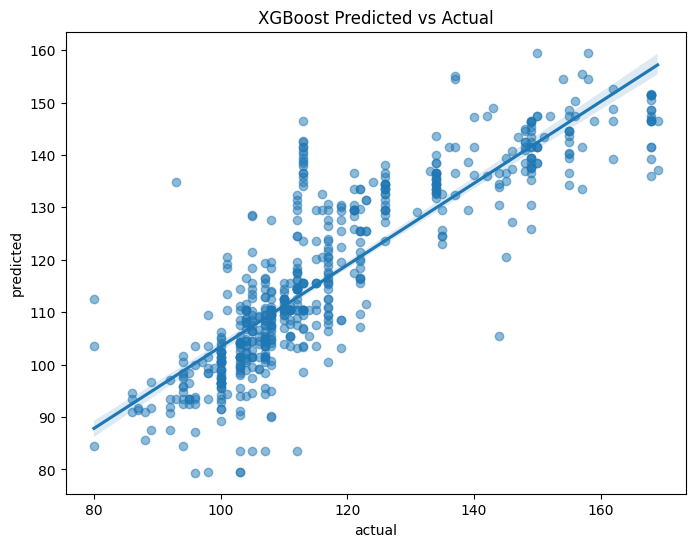

In [82]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)